In [3]:
!pip install ultralytics --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.2 MB/s eta 0:00:00a 0:00:01


In [5]:
import torch
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
import matplotlib.animation as animation
from pathlib import Path
from tqdm import tqdm
import cv2
from IPython.display import HTML
from ultralytics import YOLO

In [6]:
n_gpus = torch.cuda.device_count()

if n_gpus >= 2:
    device = "0,1"
    print(f"  Device: 2x {torch.cuda.get_device_name(0)}")
elif n_gpus == 1:
    device = 0
    print(f"  Device: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("  Device: CPU (no GPU found)")

if n_gpus >= 2:
    n_batch = 32
elif n_gpus == 1:
    n_batch = -1   # auto-detect
else:
    n_batch = 4

print(f"  Batch size: {n_batch}")

  Device: 2x Tesla T4
  Batch size: 32


In [7]:
import zipfile
from pathlib import Path

BASE_DIR    = Path("/kaggle/input/datasets/zgrcandoan/palaulm/PALA_data_InSilicoFlow")
IQ_DIR      = BASE_DIR / "IQ"
RESULTS_DIR = BASE_DIR / "Results"
GT_PATH     = BASE_DIR / "PALA_InSilicoFlow_v3_pos_Tracks_dt.mat"

OUTPUT_DIR  = Path("/kaggle/working/ulm_outputs")
YOLO_DIR    = Path("/kaggle/working/ulm_yolo_dataset")
RUNS_DIR    = Path("/kaggle/working/runs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verify
print(f"BASE_DIR exists : {BASE_DIR.exists()}")
print(f"IQ_DIR exists   : {IQ_DIR.exists()}")
print(f"GT_PATH exists  : {GT_PATH.exists()}")
print(f"IQ files found  : {len(list(IQ_DIR.glob('*.mat')))}")

BASE_DIR exists : True
IQ_DIR exists   : True
GT_PATH exists  : True
IQ files found  : 20


In [8]:
def load_iq(file_idx):
    return sio.loadmat(IQ_DIR / f"PALA_InSilicoFlow_IQ{file_idx:03d}.mat")["IQ"]

def load_matout(snr):
    res = sio.loadmat(RESULTS_DIR / f"PALA_InSilicoFlow_MatOut_multi_{snr}dB.mat")
    return [np.array(res["MatOut"][0, i], dtype=float) for i in range(N_ALGOS)]

def load_matout_vel(snr):
    res = sio.loadmat(RESULTS_DIR / f"PALA_InSilicoFlow_MatOut_multi_{snr}dB.mat")
    return [np.array(res["MatOut_vel"][0, i], dtype=float) for i in range(N_ALGOS)]

def iq_to_db(frame, dynamic_range=40):
    db = 20 * np.log10(np.abs(frame) + 1e-6)
    vmax = db.max(); vmin = vmax - dynamic_range
    return np.clip(db, vmin, vmax), vmin, vmax

def to_log(img, dynamic_range=40):
    db = 20 * np.log10(img + 1e-3)
    vmax = db.max(); vmin = vmax - dynamic_range
    return np.clip(db, vmin, vmax), vmin, vmax

def db_to_uint8(db_frame):
    mn, mx = db_frame.min(), db_frame.max()
    if mx == mn: return np.zeros_like(db_frame, dtype=np.uint8)
    return ((db_frame - mn) / (mx - mn) * 255).astype(np.uint8)

def get_frame_offset(file_idx, frames_per_file):
    return (file_idx - 1) * frames_per_file

In [9]:
BASE_DIR    = Path("/kaggle/input/datasets/zgrcandoan/palaulm/PALA_data_InSilicoFlow")
IQ_DIR      = BASE_DIR / "IQ"
RESULTS_DIR = BASE_DIR / "Results"
GT_PATH     = BASE_DIR / "PALA_InSilicoFlow_v3_pos_Tracks_dt.mat"

OUTPUT_DIR  = Path("/kaggle/working/ulm_outputs")
YOLO_DIR    = Path("/kaggle/working/ulm_yolo_dataset")
RUNS_DIR    = Path("/kaggle/working/runs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALGO_NAMES = ["no_shift", "wa", "interp_cubic", "interp_lanczos",
              "interp_spline", "gaussian_fit", "radial"]
N_ALGOS    = len(ALGO_NAMES)
ALL_SNRS   = [10, 15, 20, 25, 30, 40, 60]

YOLO_MODEL      = "yolo26n.pt"
IMG_SIZE        = 640
EPOCHS          = 10
BATCH_SIZE      = 16
BOX_HALF_PIX    = 2
FRAMES_PER_FILE = None

TRAIN_FILES = list(range(1, 17))
VAL_FILES   = list(range(17, 20))
TEST_FILES  = [20]

In [13]:
IQ = load_iq(1)
print(f"\n  IQ[001] shape  : {IQ.shape}  (Z, X, Frames)")
print(f"  dtype          : {IQ.dtype}")
print(f"  Total frames   : 20 files x {IQ.shape[2]} = {20 * IQ.shape[2]:,}")

gt      = sio.loadmat(GT_PATH)
Tracks  = gt["Tracks_dt"]
lengths = np.array([Tracks[i, 0].shape[0] for i in range(Tracks.shape[0])])
t0      = Tracks[0, 0]
print(f"\n  Tracks_dt shape : {Tracks.shape}  ({Tracks.shape[0]} trajectories)")
print(f"  Single track    : {t0.shape}  cols -> [x_pos, x_vel, z_pos, timestamp]")
print(f"  Track lengths   : min={lengths.min()}  max={lengths.max()}"
      f"  mean={lengths.mean():.1f}  median={np.median(lengths):.0f}")

res_60 = sio.loadmat(RESULTS_DIR / "PALA_InSilicoFlow_MatOut_multi_60dB.mat")
ULM    = res_60["ULM"][0, 0]
print("\n  ULM parameters:")
for field in ULM.dtype.names:
    print(f"    {field:30s} = {ULM[field][0, 0]}")

print(f"\n  Algorithms : {ALGO_NAMES}")
print(f"  SNR levels : {ALL_SNRS} dB")


  IQ[001] shape  : (84, 143, 1000)  (Z, X, Frames)
  dtype          : complex64
  Total frames   : 20 files x 1000 = 20,000

  Tracks_dt shape : (2133, 1)  (2133 trajectories)
  Single track    : (50, 4)  cols -> [x_pos, x_vel, z_pos, timestamp]
  Track lengths   : min=8  max=4963  mean=228.9  median=114

  ULM parameters:
    numberOfParticles              = 40
    res                            = 10
    max_linking_distance           = 2
    min_length                     = 15
    fwhm                           = 3
    max_gap_closing                = 0
    size                           = 84
    scale                          = 1.0
    numberOfFramesProcessed        = 1000
    interp_factor                  = 0.1

  Algorithms : ['no_shift', 'wa', 'interp_cubic', 'interp_lanczos', 'interp_spline', 'gaussian_fit', 'radial']
  SNR levels : [10, 15, 20, 25, 30, 40, 60] dB


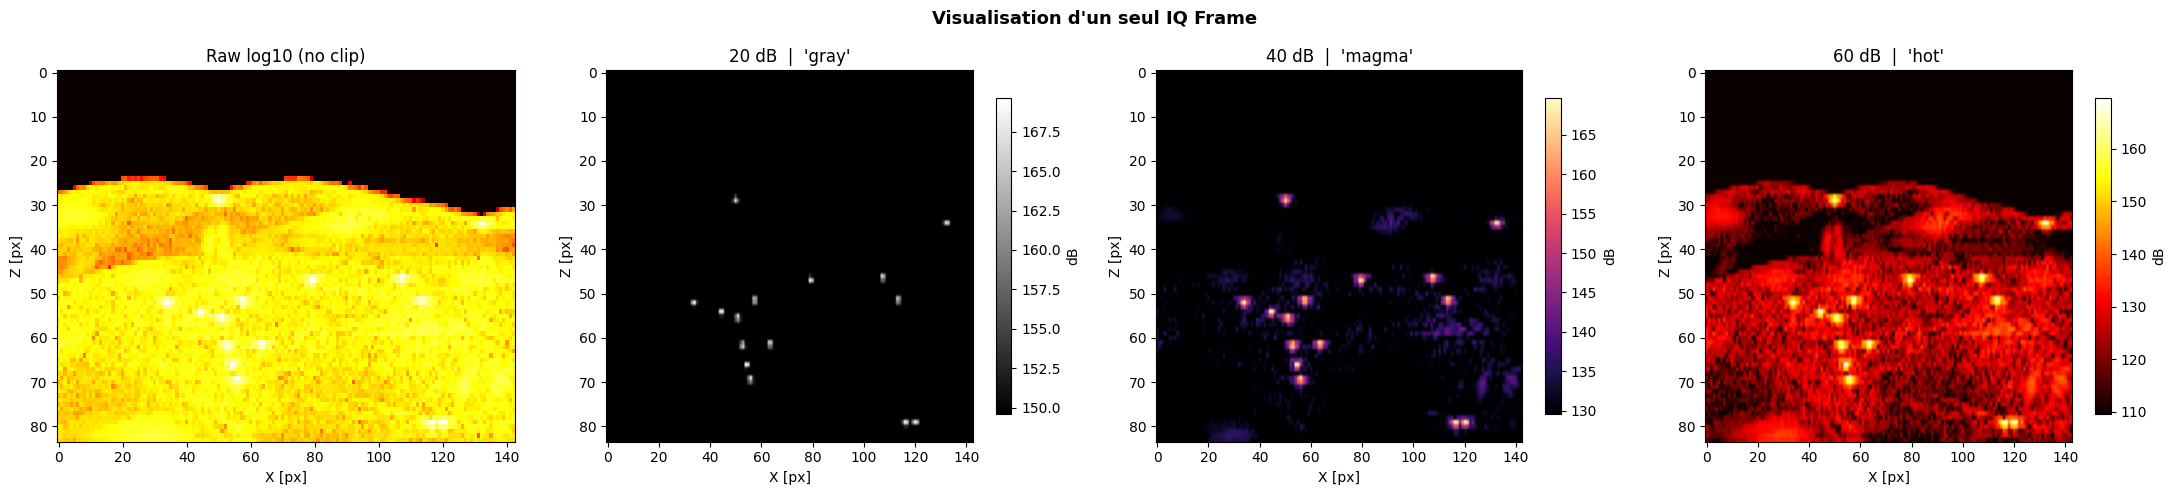

  Saved -> /kaggle/working/ulm_outputs/fig1_single_frame.png


In [14]:
frame = IQ[:, :, 0]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Visualisation d'un seul IQ Frame",
              fontsize=13, fontweight="bold")

axes[0].imshow(np.log10(np.abs(frame) + 1), cmap="hot", aspect="auto")
axes[0].set_title("Raw log10 (no clip)")
axes[0].set_xlabel("X [px]"); axes[0].set_ylabel("Z [px]")

for ax, dr, cm in zip(axes[1:], [20, 40, 60], ["gray", "magma", "hot"]):
    db, vmin, vmax = iq_to_db(frame, dr)
    im = ax.imshow(db, cmap=cm, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(f"{dr} dB  |  '{cm}'")
    ax.set_xlabel("X [px]"); ax.set_ylabel("Z [px]")
    plt.colorbar(im, ax=ax, label="dB", shrink=0.85)

plt.tight_layout()
out = OUTPUT_DIR / "fig1_single_frame.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved -> {out}")

  Total bubble positions : 488,327


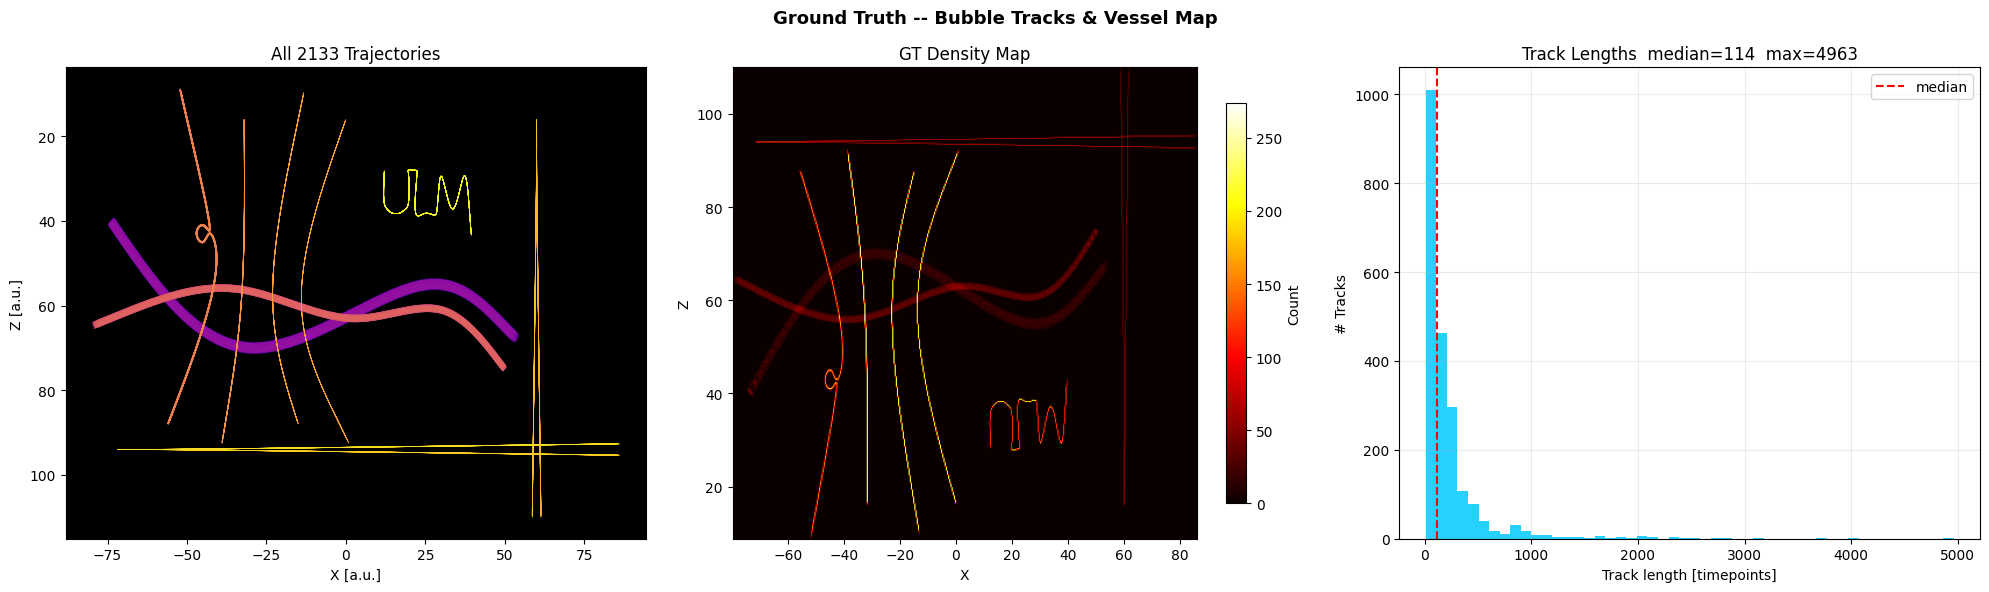

In [15]:
all_x = np.concatenate([Tracks[i, 0][:, 0] for i in range(Tracks.shape[0])])
all_z = np.concatenate([Tracks[i, 0][:, 2] for i in range(Tracks.shape[0])])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Ground Truth -- Bubble Tracks & Vessel Map",
              fontsize=13, fontweight="bold")

ax = axes[0]; ax.set_facecolor("black")
for i in range(Tracks.shape[0]):
    t = Tracks[i, 0]
    ax.plot(t[:, 0], t[:, 2], lw=0.4, alpha=0.5,
            color=plt.cm.plasma(i / Tracks.shape[0]))
ax.invert_yaxis(); ax.set_title(f"All {Tracks.shape[0]} Trajectories")
ax.set_xlabel("X [a.u.]"); ax.set_ylabel("Z [a.u.]")

h, xe, ze = np.histogram2d(all_x, all_z, bins=400)
im = axes[1].imshow(h.T, cmap="hot", aspect="auto", origin="lower",
                    extent=[xe[0], xe[-1], ze[0], ze[-1]])
axes[1].set_title("GT Density Map")
axes[1].set_xlabel("X"); axes[1].set_ylabel("Z")
plt.colorbar(im, ax=axes[1], label="Count", shrink=0.85)

axes[2].hist(lengths, bins=50, color="#00c8ff", edgecolor="none", alpha=0.85)
axes[2].axvline(np.median(lengths), color="red", lw=1.5, ls="--", label="median")
axes[2].set_xlabel("Track length [timepoints]"); axes[2].set_ylabel("# Tracks")
axes[2].set_title(f"Track Lengths  median={np.median(lengths):.0f}  max={lengths.max()}")
axes[2].legend(); axes[2].grid(True, alpha=0.25)

print(f"  Total bubble positions : {len(all_x):,}")
plt.tight_layout()
out = OUTPUT_DIR / "fig2_ground_truth.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()

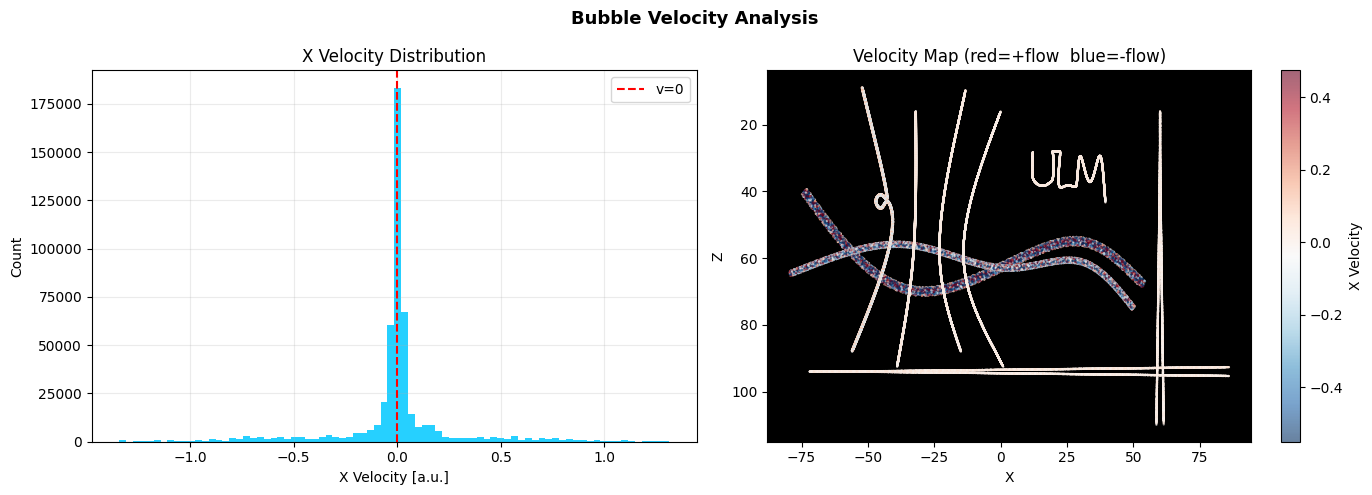

In [16]:
all_x  = np.concatenate([Tracks[i, 0][:, 0] for i in range(Tracks.shape[0])])
all_z  = np.concatenate([Tracks[i, 0][:, 2] for i in range(Tracks.shape[0])])
all_vx = np.concatenate([Tracks[i, 0][:, 1] for i in range(Tracks.shape[0])])
vp5, vp95 = np.percentile(all_vx, 5), np.percentile(all_vx, 95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bubble Velocity Analysis", fontsize=13, fontweight="bold")

axes[0].hist(all_vx, bins=80, color="#00c8ff", edgecolor="none", alpha=0.85)
axes[0].axvline(0, color="red", lw=1.5, ls="--", label="v=0")
axes[0].set_xlabel("X Velocity [a.u.]"); axes[0].set_ylabel("Count")
axes[0].set_title("X Velocity Distribution")
axes[0].legend(); axes[0].grid(True, alpha=0.25)

sc = axes[1].scatter(all_x[::4], all_z[::4], c=all_vx[::4],
                      cmap="RdBu_r", s=0.3, alpha=0.6, vmin=vp5, vmax=vp95)
axes[1].invert_yaxis(); axes[1].set_facecolor("black")
plt.colorbar(sc, ax=axes[1], label="X Velocity")
axes[1].set_title("Velocity Map (red=+flow  blue=-flow)")
axes[1].set_xlabel("X"); axes[1].set_ylabel("Z")

plt.tight_layout()
out = OUTPUT_DIR / "fig3_velocity.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()

In [17]:
n_frames=80
frames_db = [iq_to_db(IQ[:, :, f], 40)[0] for f in range(n_frames)]

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("black"); ax.set_facecolor("black")
im_obj = ax.imshow(frames_db[0], cmap="magma", animated=True, aspect="auto",
                    vmin=frames_db[0].min(), vmax=frames_db[0].max())
ttl = ax.set_title("Frame 000", color="white")
ax.set_xlabel("X [px]", color="white"); ax.set_ylabel("Z [px]", color="white")
ax.tick_params(colors="white")
plt.colorbar(im_obj, ax=ax, label="dB")

def _upd(f):
    im_obj.set_data(frames_db[f]); im_obj.set_clim(frames_db[f].min(), frames_db[f].max())
    ttl.set_text(f"Frame {f:03d}/{n_frames-1}  (40 dB)")
    return [im_obj, ttl]

ani = animation.FuncAnimation(fig, _upd, frames=n_frames, interval=80, blit=True)
out = OUTPUT_DIR / "ulm_animation.gif"
ani.save(out, writer="pillow", fps=12, dpi=100)
plt.close(fig)
HTML(ani.to_jshtml())

## Les ALgorithmes SNR = 60 db

  [0] no_shift         | max=     181 | nz=  96,715
  [1] wa               | max=     148 | nz= 115,615
  [2] interp_cubic     | max=     146 | nz=  94,694
  [3] interp_lanczos   | max=     146 | nz=  94,259
  [4] interp_spline    | max=     148 | nz=  95,257
  [5] gaussian_fit     | max=     149 | nz= 106,098
  [6] radial           | max=     148 | nz= 107,058


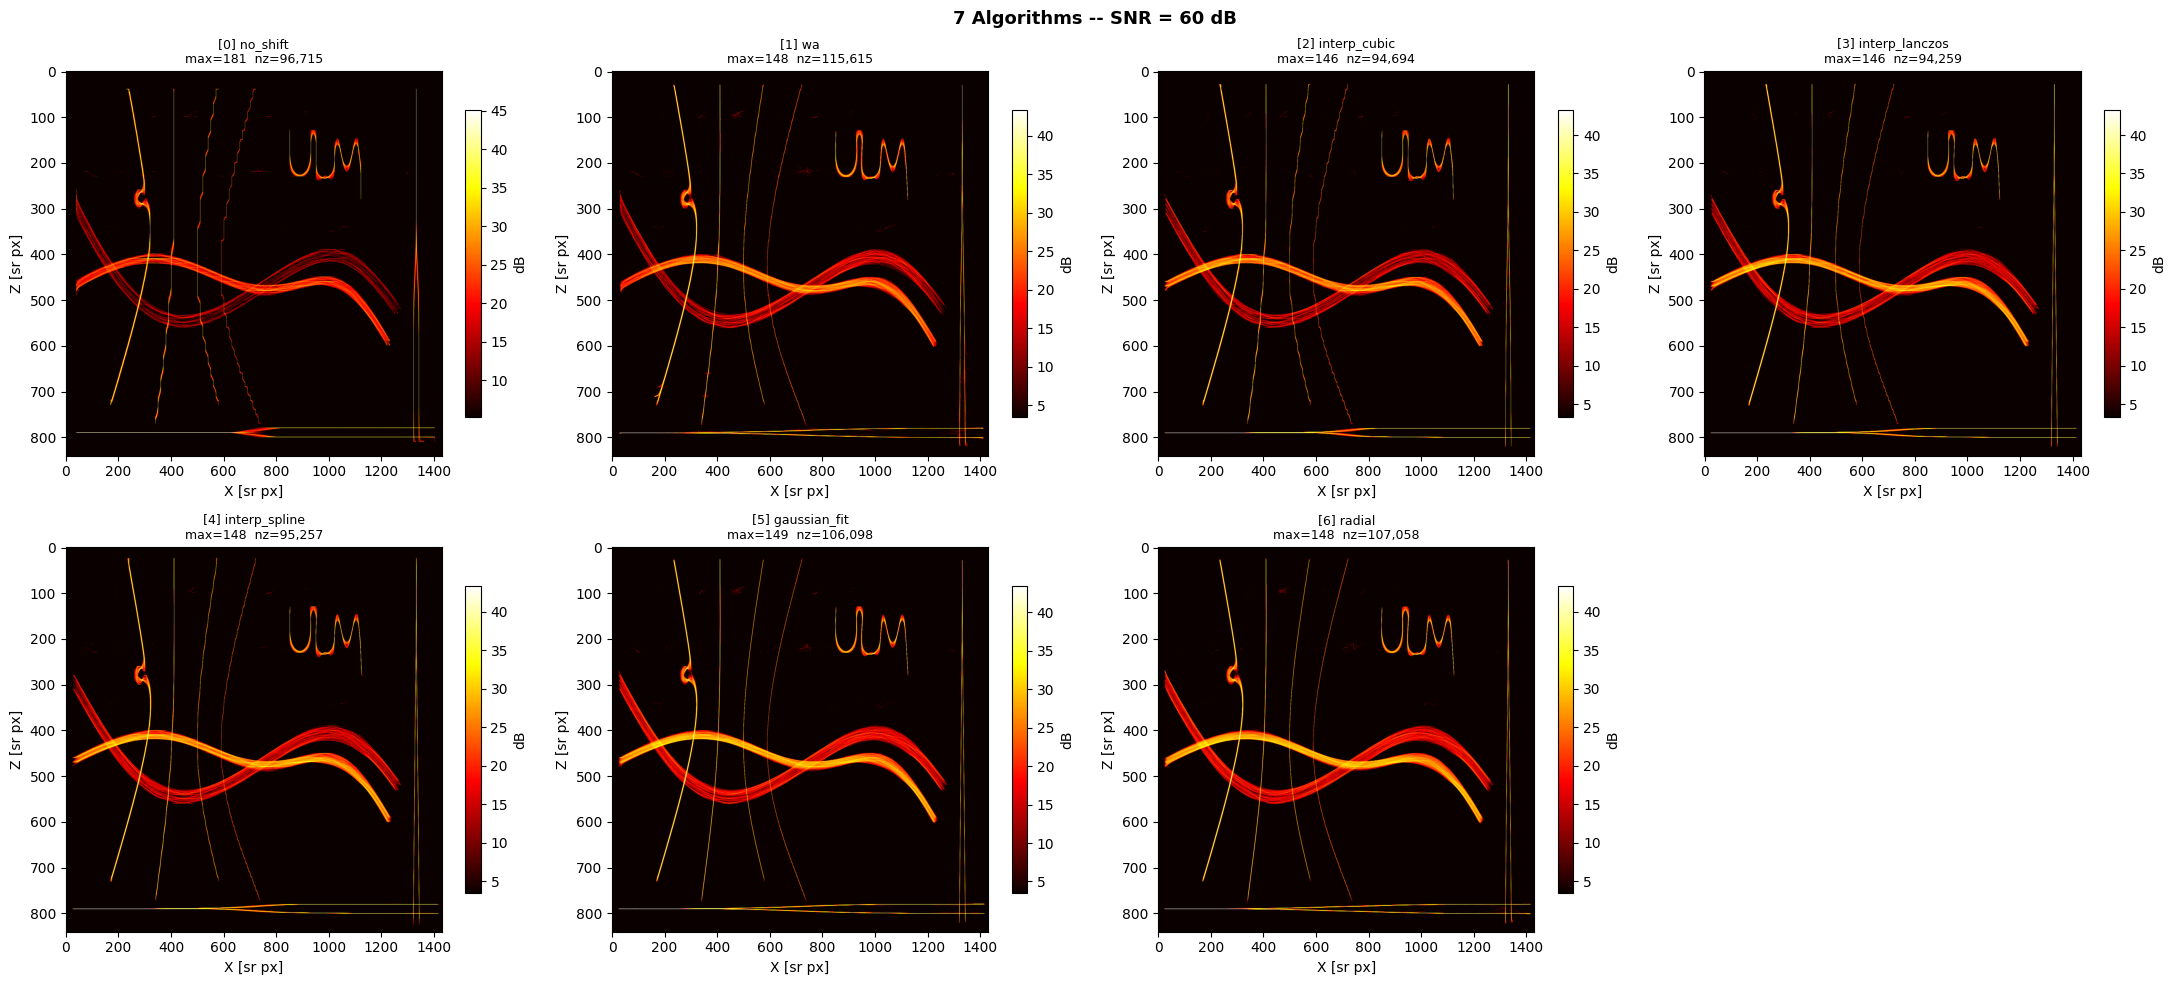

  Saved -> /kaggle/working/ulm_outputs/fig4_all_algorithms_60dB.png


In [18]:
imgs_60 = load_matout(60)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("7 Algorithms -- SNR = 60 dB", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, (img, name) in enumerate(zip(imgs_60, ALGO_NAMES)):
    img_log, vmin, vmax = to_log(img)
    im = axes[i].imshow(img_log, cmap="hot", aspect="auto", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"[{i}] {name}\nmax={img.max():.0f}  nz={np.count_nonzero(img):,}",
                      fontsize=9)
    axes[i].set_xlabel("X [sr px]"); axes[i].set_ylabel("Z [sr px]")
    plt.colorbar(im, ax=axes[i], label="dB", shrink=0.8)
    print(f"  [{i}] {name:16s} | max={img.max():>8.0f} | nz={np.count_nonzero(img):>8,}")

axes[7].set_visible(False)
plt.tight_layout()
out = OUTPUT_DIR / "fig4_all_algorithms_60dB.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved -> {out}")

  SNR 10 dB | nz=  85,167 | max=33
  SNR 15 dB | nz= 124,171 | max=78
  SNR 20 dB | nz= 112,554 | max=120
  SNR 25 dB | nz= 104,014 | max=140
  SNR 30 dB | nz= 100,958 | max=148
  SNR 40 dB | nz= 100,879 | max=148
  SNR 60 dB | nz= 107,058 | max=148


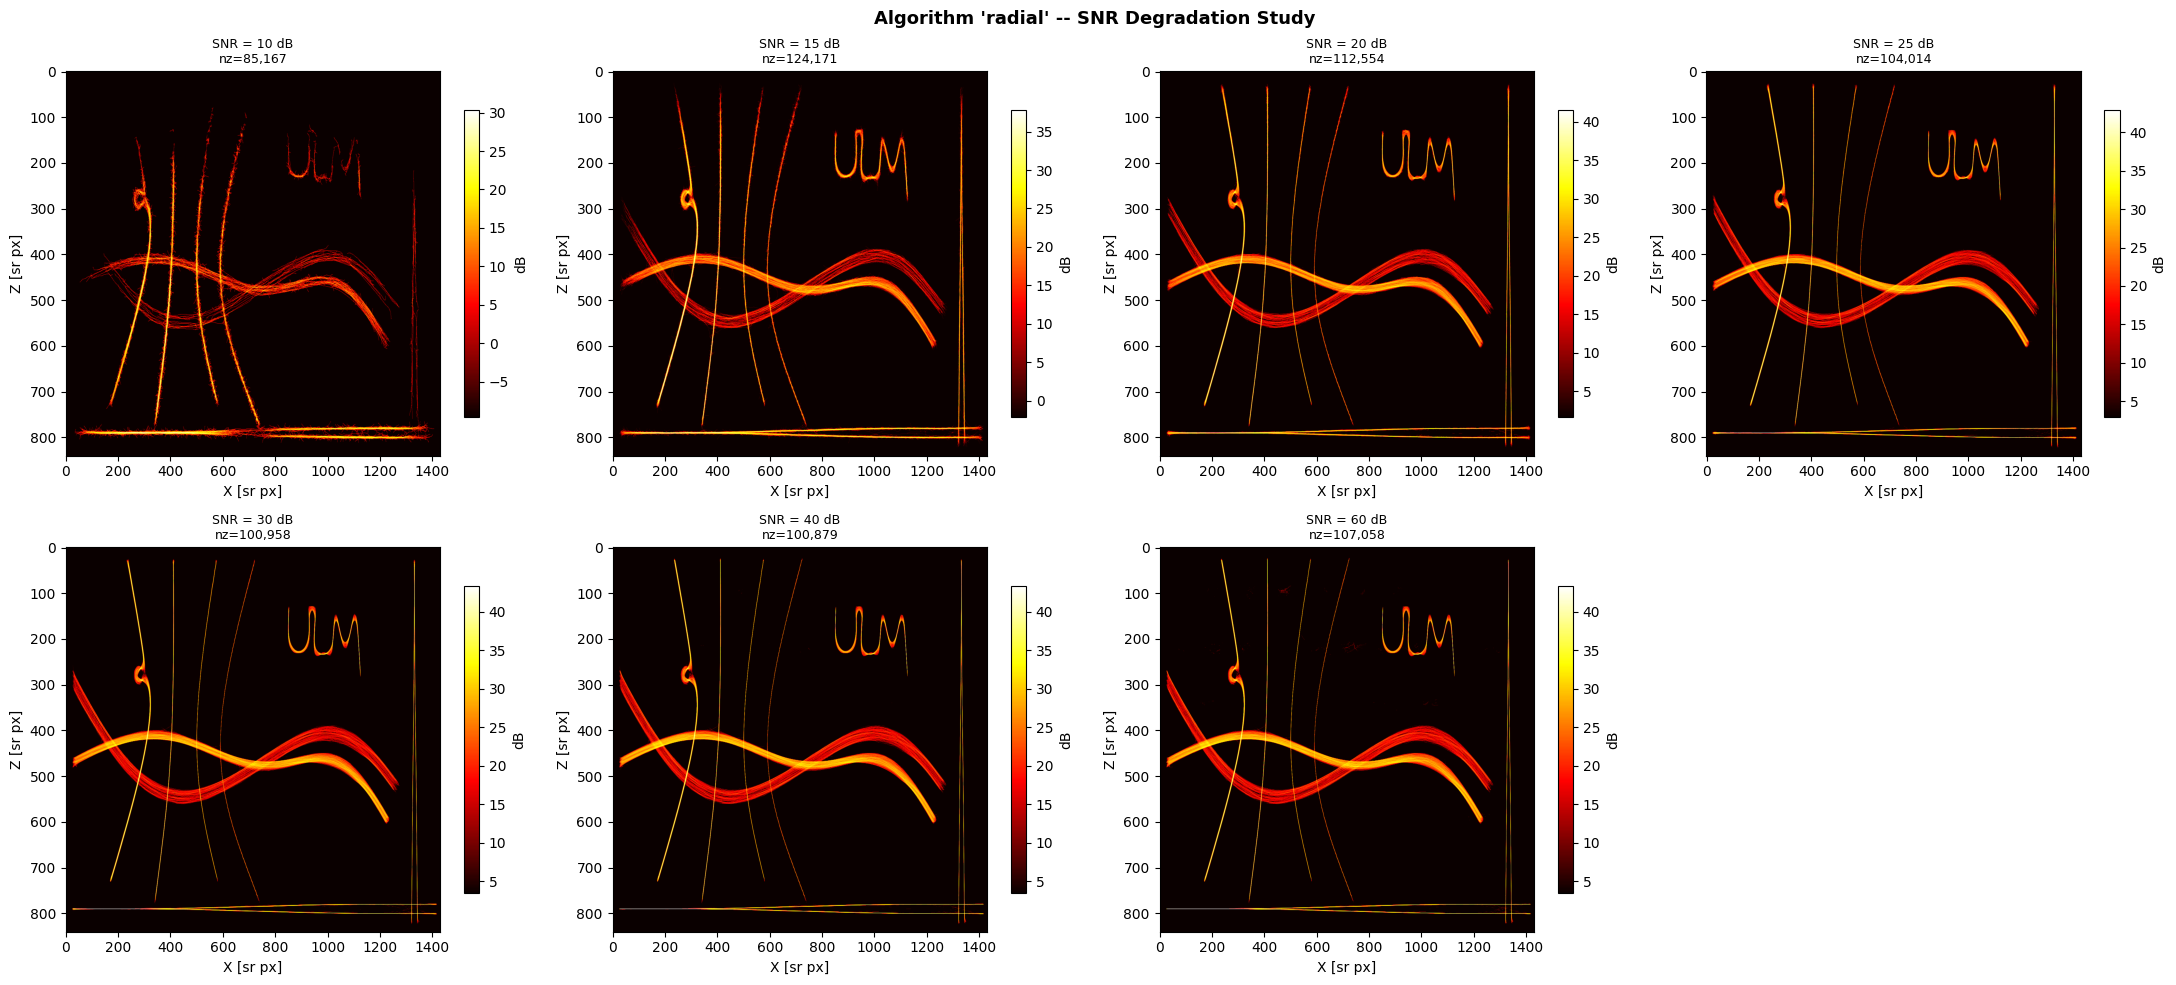

  Saved -> /kaggle/working/ulm_outputs/fig5_radial_snr_degradation.png


In [19]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Algorithm 'radial' -- SNR Degradation Study",
              fontsize=13, fontweight="bold")
axes = axes.flatten()

for j, snr in enumerate(ALL_SNRS):
    img = load_matout(snr)[6]
    img_log, vmin, vmax = to_log(img)
    im = axes[j].imshow(img_log, cmap="hot", aspect="auto", vmin=vmin, vmax=vmax)
    axes[j].set_title(f"SNR = {snr} dB\nnz={np.count_nonzero(img):,}", fontsize=9)
    axes[j].set_xlabel("X [sr px]"); axes[j].set_ylabel("Z [sr px]")
    plt.colorbar(im, ax=axes[j], label="dB", shrink=0.8)
    print(f"  SNR {snr:2d} dB | nz={np.count_nonzero(img):>8,} | max={img.max():.0f}")

axes[len(ALL_SNRS)].set_visible(False)
plt.tight_layout()
out = OUTPUT_DIR / "fig5_radial_snr_degradation.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved -> {out}")

  Resolution gain: 10x Z, 10x X


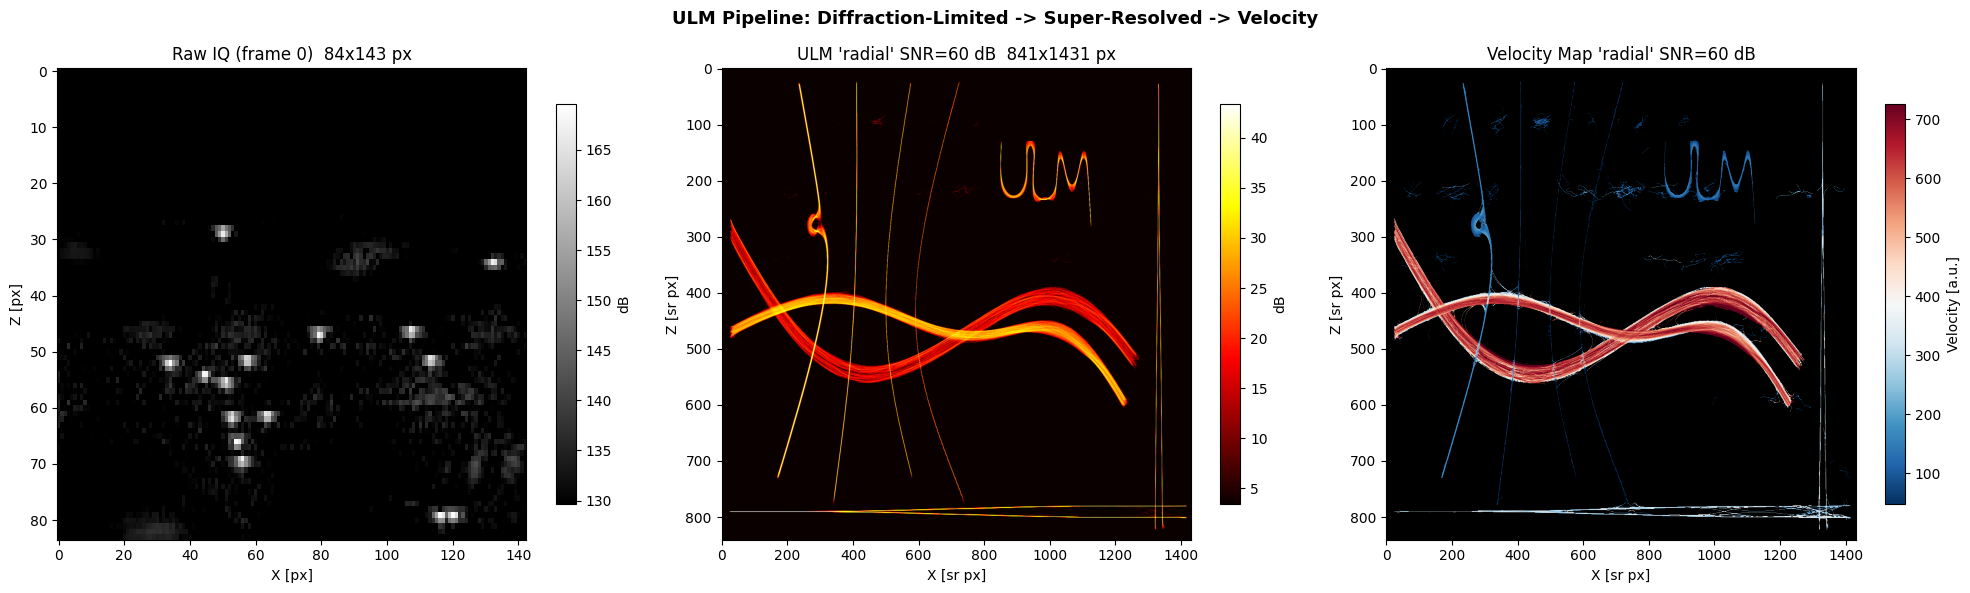

  Saved -> /kaggle/working/ulm_outputs/fig6_raw_vs_ulm_vs_velocity.png


In [20]:
ulm_img = load_matout(60)[6]
vel_img = load_matout_vel(60)[6]
raw_db,  r_vmin, r_vmax = iq_to_db(IQ[:, :, 0], 40)
ulm_log, u_vmin, u_vmax = to_log(ulm_img)
vel_nz     = vel_img[vel_img != 0]
vel_masked = np.ma.masked_where(vel_img == 0, vel_img)
vp5, vp95  = np.percentile(vel_nz, 5), np.percentile(vel_nz, 95)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("ULM Pipeline: Diffraction-Limited -> Super-Resolved -> Velocity",
              fontsize=13, fontweight="bold")

im0 = axes[0].imshow(raw_db, cmap="gray", aspect="auto", vmin=r_vmin, vmax=r_vmax)
axes[0].set_title(f"Raw IQ (frame 0)  {IQ.shape[0]}x{IQ.shape[1]} px")
axes[0].set_xlabel("X [px]"); axes[0].set_ylabel("Z [px]")
plt.colorbar(im0, ax=axes[0], label="dB", shrink=0.85)

im1 = axes[1].imshow(ulm_log, cmap="hot", aspect="auto", vmin=u_vmin, vmax=u_vmax)
axes[1].set_title(f"ULM 'radial' SNR=60 dB  {ulm_img.shape[0]}x{ulm_img.shape[1]} px")
axes[1].set_xlabel("X [sr px]"); axes[1].set_ylabel("Z [sr px]")
plt.colorbar(im1, ax=axes[1], label="dB", shrink=0.85)

axes[2].imshow(np.zeros_like(vel_img), cmap="gray", aspect="auto")
im2 = axes[2].imshow(vel_masked, cmap="RdBu_r", aspect="auto", vmin=vp5, vmax=vp95)
axes[2].set_title("Velocity Map 'radial' SNR=60 dB")
axes[2].set_xlabel("X [sr px]"); axes[2].set_ylabel("Z [sr px]")
plt.colorbar(im2, ax=axes[2], label="Velocity [a.u.]", shrink=0.85)

print(f"  Resolution gain: {ulm_img.shape[0]//IQ.shape[0]}x Z, "
      f"{ulm_img.shape[1]//IQ.shape[1]}x X")
plt.tight_layout()
out = OUTPUT_DIR / "fig6_raw_vs_ulm_vs_velocity.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved -> {out}")

  SNR 10 dB loaded
  SNR 15 dB loaded
  SNR 20 dB loaded
  SNR 25 dB loaded
  SNR 30 dB loaded
  SNR 40 dB loaded
  SNR 60 dB loaded


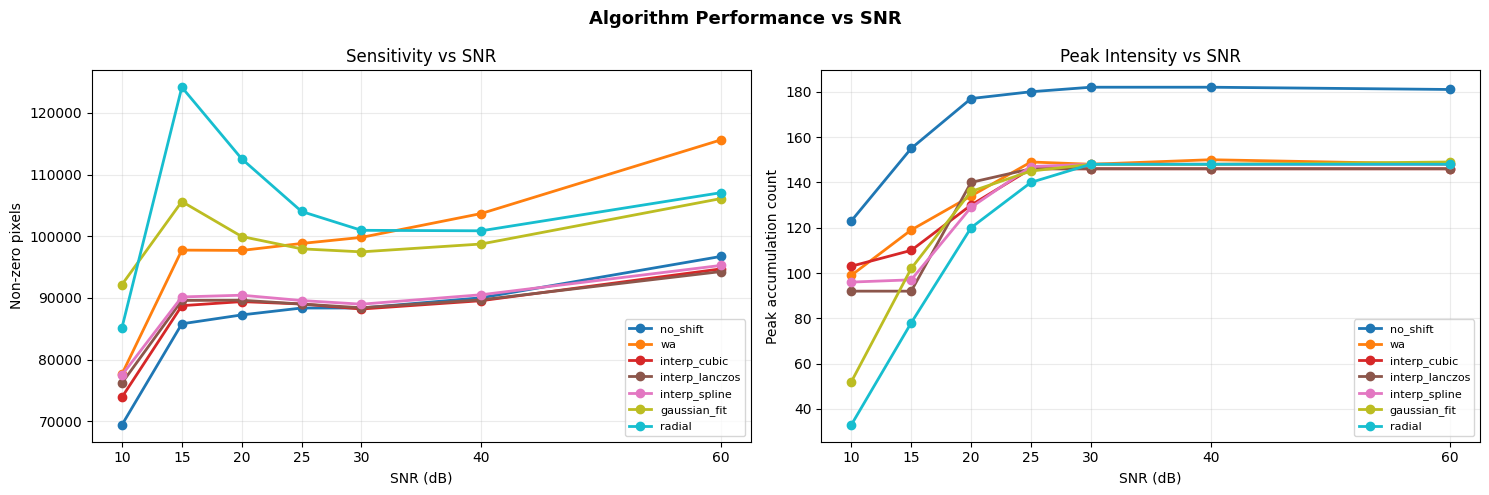

  Saved -> /kaggle/working/ulm_outputs/fig7_quantitative.png

  Ranking at SNR=10 dB:
  #1  gaussian_fit      nz=  92,152  peak=    52
  #2  radial            nz=  85,167  peak=    33
  #3  wa                nz=  77,646  peak=    99
  #4  interp_spline     nz=  77,483  peak=    96
  #5  interp_lanczos    nz=  76,188  peak=    92
  #6  interp_cubic      nz=  73,889  peak=   103
  #7  no_shift          nz=  69,402  peak=   123


In [21]:
nz_matrix  = np.zeros((N_ALGOS, len(ALL_SNRS)))
max_matrix = np.zeros((N_ALGOS, len(ALL_SNRS)))

for j, snr in enumerate(ALL_SNRS):
    imgs = load_matout(snr)
    for i, img in enumerate(imgs):
        nz_matrix[i, j]  = np.count_nonzero(img)
        max_matrix[i, j] = img.max()
    print(f"  SNR {snr:2d} dB loaded")

colors = plt.cm.tab10(np.linspace(0, 1, N_ALGOS))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Algorithm Performance vs SNR", fontsize=13, fontweight="bold")

for i, (name, color) in enumerate(zip(ALGO_NAMES, colors)):
    axes[0].plot(ALL_SNRS, nz_matrix[i],  "o-", label=name, color=color, lw=2, ms=6)
    axes[1].plot(ALL_SNRS, max_matrix[i], "o-", label=name, color=color, lw=2, ms=6)

for ax, ylabel, title in zip(
        axes, ["Non-zero pixels", "Peak accumulation count"],
        ["Sensitivity vs SNR", "Peak Intensity vs SNR"]):
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.25); ax.set_xticks(ALL_SNRS)

plt.tight_layout()
out = OUTPUT_DIR / "fig7_quantitative.png"
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved -> {out}")

print("\n  Ranking at SNR=10 dB:")
for rank, idx in enumerate(np.argsort(nz_matrix[:, 0])[::-1]):
    print(f"  #{rank+1}  {ALGO_NAMES[idx]:16s}  "
          f"nz={nz_matrix[idx, 0]:>8,.0f}  peak={max_matrix[idx, 0]:>6.0f}")


## Creation dataset pour YOLO

In [28]:
gt     = sio.loadmat(GT_PATH)
Tracks = gt["Tracks_dt"]
IQ0    = load_iq(1)
Z, X, F_per_file = IQ0.shape

all_x = np.concatenate([Tracks[i,0][:,0] for i in range(Tracks.shape[0])])
all_z = np.concatenate([Tracks[i,0][:,2] for i in range(Tracks.shape[0])])
GT_X_MIN = all_x.min();  GT_X_MAX = all_x.max()
GT_Z_MIN = all_z.min();  GT_Z_MAX = all_z.max()
GT_SCALE_X = (X - 1) / (GT_X_MAX - GT_X_MIN)
GT_SCALE_Z = (Z - 1) / (GT_Z_MAX - GT_Z_MIN)

print(f"  IQ shape     : {IQ0.shape}")
print(f"  GT x range   : {GT_X_MIN:.2f} to {GT_X_MAX:.2f}  scale={GT_SCALE_X:.4f}")
print(f"  GT z range   : {GT_Z_MIN:.2f} to {GT_Z_MAX:.2f}  scale={GT_SCALE_Z:.4f}")
print(f"  Box half     : {BOX_HALF_PIX} px")

  IQ shape     : (84, 143, 1000)
  GT x range   : -79.88 to 86.19  scale=0.8551
  GT z range   : 8.79 to 110.01  scale=0.8200
  Box half     : 2 px


In [32]:
def build_split(Tracks, iq_shape, file_list, split, frames_per_file,
                gt_x_min, gt_scale_x, gt_z_min, gt_scale_z,
                box_half=BOX_HALF_PIX):
    Z, X, _ = iq_shape
    img_dir  = YOLO_DIR / split / "images"
    lbl_dir  = YOLO_DIR / split / "labels"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    # Build bubble_map with PIXEL coordinates
    bubble_map = {}
    for i in range(Tracks.shape[0]):
        for row in Tracks[i, 0]:
            x_pos, _, z_pos, ts = row
            frame_global = int(round(ts)) - 1
            # Convert physical → pixel
            px = (x_pos - gt_x_min) * gt_scale_x
            pz = (z_pos - gt_z_min) * gt_scale_z
            bubble_map.setdefault(frame_global, []).append((px, pz))

    n_saved = 0
    for file_idx in tqdm(file_list, desc=f"  {split}"):
        try:
            IQ = load_iq(file_idx)
        except FileNotFoundError:
            print(f"    WARNING: IQ{file_idx:03d}.mat not found -- skipping.")
            continue

        n_frames = IQ.shape[2] if FRAMES_PER_FILE is None else min(FRAMES_PER_FILE, IQ.shape[2])
        offset   = get_frame_offset(file_idx, frames_per_file)

        for f in range(n_frames):
            frame_global = offset + f
            img_name     = f"iq{file_idx:03d}_f{f:04d}.png"

            db_frame = iq_to_db(IQ[:, :, f], 40)[0]
            img_bgr  = cv2.cvtColor(db_to_uint8(db_frame), cv2.COLOR_GRAY2BGR)
            cv2.imwrite(str(img_dir / img_name), img_bgr)

            bubbles = bubble_map.get(frame_global, [])
            with open(lbl_dir / img_name.replace(".png", ".txt"), "w") as fh:
                seen = set()
                for bx, bz in bubbles:
                    # bx, bz are now already in pixel space
                    px = np.clip(bx, 0, X - 1)
                    pz = np.clip(bz, 0, Z - 1)
                    cx = round(np.clip(px / X, box_half / X, 1 - box_half / X), 6)
                    cy = round(np.clip(pz / Z, box_half / Z, 1 - box_half / Z), 6)
                    bw = (2 * box_half) / X
                    bh = (2 * box_half) / Z
                    key = (cx, cy)
                    if key in seen:
                        continue
                    seen.add(key)
                    fh.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
            n_saved += 1

    print(f"  -> {n_saved} images written to {YOLO_DIR / split}")


if YOLO_DIR.exists():
    shutil.rmtree(YOLO_DIR)

build_split(Tracks, IQ0.shape, TRAIN_FILES, "train", F_per_file,
            GT_X_MIN, GT_SCALE_X, GT_Z_MIN, GT_SCALE_Z)
build_split(Tracks, IQ0.shape, VAL_FILES,   "val",   F_per_file,
            GT_X_MIN, GT_SCALE_X, GT_Z_MIN, GT_SCALE_Z)
build_split(Tracks, IQ0.shape, TEST_FILES,  "test",  F_per_file,
            GT_X_MIN, GT_SCALE_X, GT_Z_MIN, GT_SCALE_Z)

yaml_path = write_yolo_yaml()

# Verify distribution is now balanced
for split in ["train", "val", "test"]:
    lbl_files = list((YOLO_DIR / split / "labels").glob("*.txt"))
    n_boxes   = sum(sum(1 for ln in open(p) if ln.strip()) for p in lbl_files)
    # Sample cx values to verify full-width coverage
    cx_vals = []
    for lf in lbl_files[:200]:
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cx_vals.append(float(parts[1]))
    cx_vals = np.array(cx_vals) if cx_vals else np.array([0])
    print(f"  {split:5s}: {len(lbl_files):5d} frames | {n_boxes:8,} labels | "
          f"cx range {cx_vals.min():.3f}–{cx_vals.max():.3f}  "
          f"L/R={( cx_vals<0.5).sum()}/{(cx_vals>=0.5).sum()}")

  train: 100%|██████████| 16/16 [00:25<00:00,  1.59s/it]


  -> 16000 images written to /kaggle/working/ulm_yolo_dataset/train


  val: 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]


  -> 3000 images written to /kaggle/working/ulm_yolo_dataset/val


  test: 100%|██████████| 1/1 [00:01<00:00,  1.77s/it]


  -> 1000 images written to /kaggle/working/ulm_yolo_dataset/test
  YOLO dataset config -> /kaggle/working/ulm_yolo_dataset/dataset.yaml
  train: 16000 frames |  388,224 labels | cx range 0.014–0.986  L/R=3493/1292
  val  :  3000 frames |   71,357 labels | cx range 0.014–0.986  L/R=3460/1232
  test :  1000 frames |   28,745 labels | cx range 0.014–0.986  L/R=4188/1623


## Fine Tune YOLO26n

In [33]:
model = YOLO(YOLO_MODEL)
print(f"  Model: {YOLO_MODEL}  |  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}")

model.train(
    data         = str(yaml_path),
    epochs       = 100,
    patience     = 15,
    imgsz        = IMG_SIZE,
    batch        = n_batch,
    fraction     = 0.25,
    cache        = True,
    project      = str(RUNS_DIR),
    name         = "ulm_bubble_detector",
    exist_ok     = True,
    device       = device,
    workers      = 4,
    # augment = True
    mosaic       = 0.0,
    close_mosaic = 0,
    degrees      = 0.0,
    fliplr       = 0.0,
    flipud       = 0.0,
    scale        = 0.0,
    translate    = 0.1,
    box          = 10.0,
    cls          = 0.5,
)

best_ckpt = RUNS_DIR / "ulm_bubble_detector" / "weights" / "best.pt"
print(f"\n  Best weights -> {best_ckpt}")

  Model: yolo26n.pt  |  Epochs: 10  |  Batch: 16
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=10.0, cache=True, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/ulm_yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=0.25, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mos

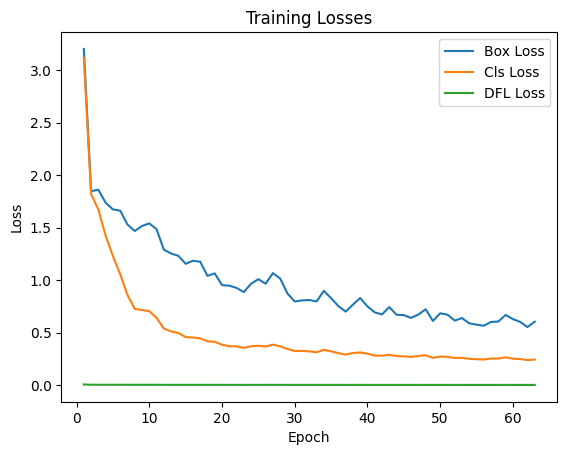

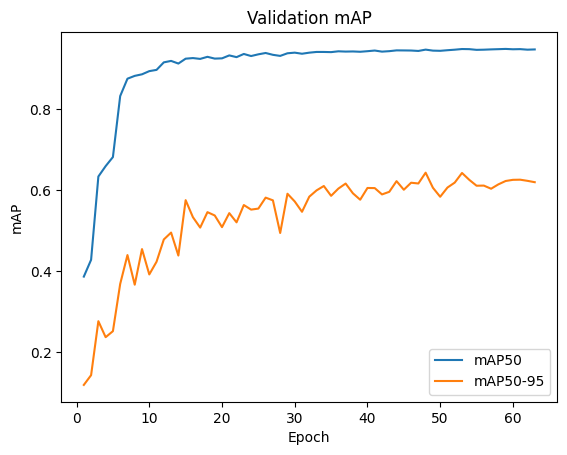

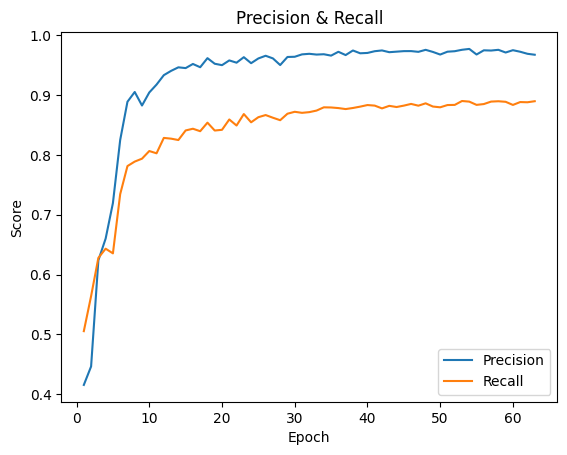

In [52]:
import pandas as pd

results_path = Path("/kaggle/working/runs/ulm_bubble_detector/results.csv")
df = pd.read_csv(results_path)

plt.figure()
plt.plot(df["epoch"], df["train/box_loss"])
plt.plot(df["epoch"], df["train/cls_loss"])
plt.plot(df["epoch"], df["train/dfl_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend(["Box Loss", "Cls Loss", "DFL Loss"])
plt.show()

plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"])
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"])
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation mAP")
plt.legend(["mAP50", "mAP50-95"])
plt.show()

plt.figure()
plt.plot(df["epoch"], df["metrics/precision(B)"])
plt.plot(df["epoch"], df["metrics/recall(B)"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision & Recall")
plt.legend(["Precision", "Recall"])
plt.show()

## Evaluation YOLO

In [34]:
model   = YOLO(str(best_ckpt))
metrics = model.val(data=str(yaml_path), split="test", imgsz=IMG_SIZE)

print(f"\n  YOLO test-set metrics:")
print(f"    Precision : {metrics.box.mp:.4f}")
print(f"    Recall    : {metrics.box.mr:.4f}")
print(f"    mAP@50    : {metrics.box.map50:.4f}")
print(f"    mAP@50-95 : {metrics.box.map:.4f}")

print("\n  Computing ULM localisation accuracy ...")

gt      = sio.loadmat(GT_PATH)
Tracks  = gt["Tracks_dt"]
IQ0     = load_iq(TEST_FILES[0])
Z, X, _ = IQ0.shape

# Convert GT physical → pixel
all_x = np.concatenate([Tracks[i,0][:,0] for i in range(Tracks.shape[0])])
all_z = np.concatenate([Tracks[i,0][:,2] for i in range(Tracks.shape[0])])
gt_x_min, gt_x_max = all_x.min(), all_x.max()
gt_z_min, gt_z_max = all_z.min(), all_z.max()
scale_x = (X - 1) / (gt_x_max - gt_x_min)
scale_z = (Z - 1) / (gt_z_max - gt_z_min)
print(f"  scale_x={scale_x:.4f}  scale_z={scale_z:.4f}")

bubble_map = {}
for i in range(Tracks.shape[0]):
    for row in Tracks[i, 0]:
        x_pos, _, z_pos, ts = row
        frame_global = int(round(ts)) - 1
        x_px = (x_pos - gt_x_min) * scale_x
        z_px = (z_pos - gt_z_min) * scale_z
        bubble_map.setdefault(frame_global, []).append((x_px, z_px))

delta_list = [1, 2, 3]
tp = {d: 0 for d in delta_list}
fp = {d: 0 for d in delta_list}
fn = {d: 0 for d in delta_list}

test_imgs = sorted((YOLO_DIR / "test" / "images").glob("*.png"))[:200]

for img_path in tqdm(test_imgs, desc="  eval"):
    parts        = img_path.stem.split("_")
    file_idx     = int(parts[0][2:])
    frame_idx    = int(parts[1][1:])
    frame_global = get_frame_offset(file_idx, IQ0.shape[2]) + frame_idx
    gt_bubbles   = bubble_map.get(frame_global, [])

    res   = model.predict(str(img_path), imgsz=IMG_SIZE, conf=0.10, verbose=False)
    boxes = res[0].boxes
    preds = []
    if boxes is not None and len(boxes) > 0:
        for box in boxes.xyxy.cpu().numpy():
            cx_iq = (box[0] + box[2]) / 2
            cz_iq = (box[1] + box[3]) / 2
            preds.append((cx_iq, cz_iq))

    for delta in delta_list:
        matched_gt   = set()
        matched_pred = set()
        for pi, (px, pz) in enumerate(preds):
            for gi, (gx, gz) in enumerate(gt_bubbles):
                if gi in matched_gt:
                    continue
                if np.hypot(px - gx, pz - gz) <= delta:
                    matched_gt.add(gi); matched_pred.add(pi); break
        tp[delta] += len(matched_gt)
        fp[delta] += len(preds) - len(matched_pred)
        fn[delta] += len(gt_bubbles) - len(matched_gt)

print(f"\n  ULM localisation ({len(test_imgs)} frames):")
print(f"  {'delta(px)':<10} {'TP':>8} {'FP':>8} {'FN':>8} {'Prec':>9} {'Rec':>8} {'F1':>8}")
for d in delta_list:
    P  = tp[d] / (tp[d] + fp[d] + 1e-9)
    R  = tp[d] / (tp[d] + fn[d] + 1e-9)
    F1 = 2 * P * R / (P + R + 1e-9)
    print(f"  {d:<10d} {tp[d]:>8,} {fp[d]:>8,} {fn[d]:>8,} "
          f"{P:>9.4f} {R:>8.4f} {F1:>8.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 363.1±87.8 MB/s, size: 9.2 KB)
val: Scanning /kaggle/working/ulm_yolo_dataset/test/labels... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 1.5Kit/s 0.7s1ss
val: New cache created: /kaggle/working/ulm_yolo_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 6.5it/s 9.7s<0.1s
                   all       1000      28745      0.976      0.872      0.932      0.648
Speed: 0.5ms preprocess, 2.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2

  YOLO test-set metrics:
    Precision : 0.9763
    Recall    : 0.8717
    mAP@50    : 0.9315
    mAP@50-95 : 0.6479

  Computing ULM localisation accuracy ...
  scale_x=0.8551  s

  eval: 100%|██████████| 200/200 [00:02<00:00, 79.19it/s]


  ULM localisation (200 frames):
  delta(px)        TP       FP       FN      Prec      Rec       F1
  1             2,903    2,269    2,282    0.5613   0.5599   0.5606
  2             3,578    1,594    1,607    0.6918   0.6901   0.6909
  3             3,687    1,485    1,498    0.7129   0.7111   0.7120


## Reconstruction


  Detecting on IQ020 (1000 frames) ...


  detect: 100%|██████████| 1000/1000 [00:11<00:00, 87.09it/s]


  Total valid detections : 29,596
  X range : 4.7 – 123.7
  Z range : 1.9 – 76.6
  MatOut_DL max    : 19
  MatOut_DL nonzero: 18,047
  Saved -> /kaggle/working/ulm_outputs/DL_detections.mat


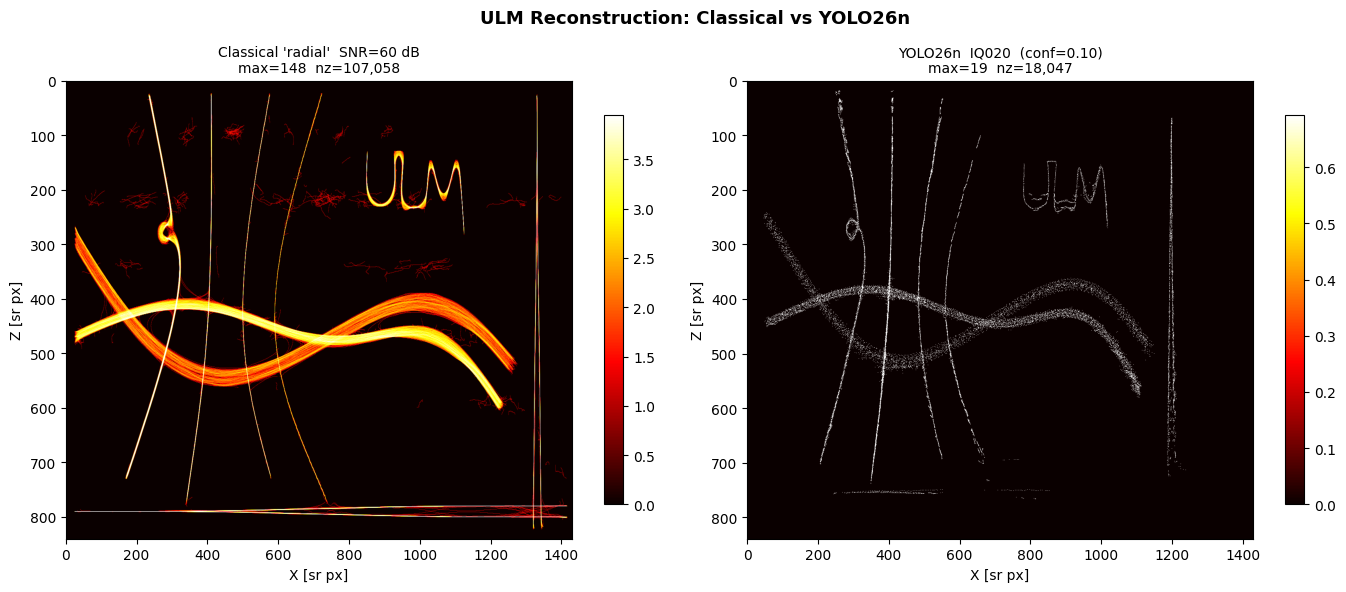

  Saved -> /kaggle/working/ulm_outputs/fig8_classical_vs_dl_ulm.png


In [35]:
model    = YOLO(str(best_ckpt))
IQ       = load_iq(TEST_FILES[0])
Z, X, NF = IQ.shape
RES      = 10

detections = []
print(f"\n  Detecting on IQ{TEST_FILES[0]:03d} ({NF} frames) ...")

for f in tqdm(range(NF), desc="  detect"):
    db_frame = iq_to_db(IQ[:, :, f], 40)[0]
    img_bgr  = cv2.cvtColor(db_to_uint8(db_frame), cv2.COLOR_GRAY2BGR)
    res      = model.predict(img_bgr, imgsz=IMG_SIZE, conf=0.10, verbose=False)
    boxes    = res[0].boxes
    if boxes is None or len(boxes) == 0:
        continue

    mag = np.abs(IQ[:, :, f])
    for box in boxes.xyxy.cpu().numpy():
        cx_iq = (box[0] + box[2]) / 2   # already in IQ pixel space
        cz_iq = (box[1] + box[3]) / 2
        if not (0 <= cx_iq < X and 0 <= cz_iq < Z):
            continue
        xi = int(cx_iq)
        zi = int(cz_iq)
        detections.append([float(mag[zi, xi]), float(cx_iq), float(cz_iq), float(f + 1)])

detections = np.array(detections)
print(f"  Total valid detections : {len(detections):,}")
print(f"  X range : {detections[:,1].min():.1f} – {detections[:,1].max():.1f}")
print(f"  Z range : {detections[:,2].min():.1f} – {detections[:,2].max():.1f}")

# Accumulate into super-resolution grid
MatOut_DL = np.zeros((Z * RES, X * RES), dtype=float)
for _, bx, bz, _ in detections:
    ix = int(np.clip(round(bx * RES), 0, X * RES - 1))
    iz = int(np.clip(round(bz * RES), 0, Z * RES - 1))
    MatOut_DL[iz, ix] += 1

print(f"  MatOut_DL max    : {MatOut_DL.max():.0f}")
print(f"  MatOut_DL nonzero: {np.count_nonzero(MatOut_DL):,}")

# Save .mat
sio.savemat(str(OUTPUT_DIR / "DL_detections.mat"),
            {"detections": detections,
             "columns": "intensity, x_pixel, z_pixel, frame_number"})
print(f"  Saved -> {OUTPUT_DIR / 'DL_detections.mat'}")

# ── Plot — robust, no dependency on to_log ───────────────────────────
classical = load_matout(60)[6]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ULM Reconstruction: Classical vs YOLO26n", fontsize=13, fontweight="bold")

for ax, img, title in zip(
        axes,
        [classical, MatOut_DL],
        ["Classical 'radial'  SNR=60 dB",
         f"YOLO26n  IQ{TEST_FILES[0]:03d}  (conf=0.10)"]):

    if img.max() > 0:
        log_img = np.log1p(img)                  # log1p never fails
        vmax    = np.percentile(log_img, 99.5)   # robust colorscale
        im = ax.imshow(log_img, cmap="hot", aspect="auto", vmin=0, vmax=vmax)
    else:
        im = ax.imshow(np.zeros_like(img), cmap="hot", aspect="auto")
        ax.text(0.5, 0.5, "No detections", transform=ax.transAxes,
                ha="center", va="center", color="white", fontsize=12)

    ax.set_title(f"{title}\nmax={img.max():.0f}  nz={np.count_nonzero(img):,}",
                 fontsize=10)
    ax.set_xlabel("X [sr px]")
    ax.set_ylabel("Z [sr px]")
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()
out = OUTPUT_DIR / "fig8_classical_vs_dl_ulm.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved -> {out}")

In [37]:
import shutil
shutil.copy(best_ckpt, OUTPUT_DIR / "best_yolo26n_fixed.pt")

PosixPath('/kaggle/working/ulm_outputs/best_yolo26n_fixed.pt')

## Test Model

In [38]:
classical_scaled = load_matout(60)[6] / 20.0
print(f"Classical (1 file estimate) nz={np.count_nonzero(classical_scaled > 0.5):,}")

Classical (1 file estimate) nz=43,498


In [40]:
def add_noise(IQ, snr_db):
    signal_power = np.mean(np.abs(IQ)**2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = np.sqrt(noise_power/2) * (np.random.randn(*IQ.shape)
                   + 1j*np.random.randn(*IQ.shape)).astype(np.complex64)
    return IQ + noise

def run_yolo_on_iq(model, IQ, conf=0.10):
    Z, X, NF = IQ.shape
    MatOut = np.zeros((Z * RES, X * RES), dtype=float)
    n_det  = 0
    for f in range(NF):
        db_frame = iq_to_db(IQ[:, :, f], 40)[0]
        img_bgr  = cv2.cvtColor(db_to_uint8(db_frame), cv2.COLOR_GRAY2BGR)
        res      = model.predict(img_bgr, imgsz=IMG_SIZE, conf=conf, verbose=False)
        boxes    = res[0].boxes
        if boxes is None or len(boxes) == 0:
            continue
        for box in boxes.xyxy.cpu().numpy():
            cx = (box[0] + box[2]) / 2
            cz = (box[1] + box[3]) / 2
            if not (0 <= cx < X and 0 <= cz < Z):
                continue
            ix = int(np.clip(round(cx * RES), 0, X * RES - 1))
            iz = int(np.clip(round(cz * RES), 0, Z * RES - 1))
            MatOut[iz, ix] += 1
            n_det += 1
    return MatOut, n_det

# ── Run SNR study ─────────────────────────────────────────────────────
RES        = 10
SNR_LEVELS = [10, 15, 20, 25, 30, 40, 60]
IQ_clean   = load_iq(TEST_FILES[0])
Z, X, NF   = IQ_clean.shape

model = YOLO(str(best_ckpt))

dl_results  = {}   # snr → {"MatOut", "n_det", "nz"}
cls_results = {}   # snr → {"MatOut", "nz"}

print("Running YOLO26n SNR study...")
print(f"{'SNR':>6} {'DL n_det':>10} {'DL nz':>10} {'CLS nz':>10}")
print("-" * 42)

for snr in SNR_LEVELS:
    # ── DL on noisy IQ ──
    IQ_noisy        = add_noise(IQ_clean, snr) if snr < 60 else IQ_clean
    MatOut_DL, ndet = run_yolo_on_iq(model, IQ_noisy, conf=0.10)
    nz_dl           = np.count_nonzero(MatOut_DL)

    # ── Classical from precomputed results (all 20k frames, scale to 1k) ──
    MatOut_cls = load_matout(snr)[6]          # radial, full 20k frames
    nz_cls     = np.count_nonzero(MatOut_cls)

    dl_results[snr]  = {"MatOut": MatOut_DL,  "n_det": ndet, "nz": nz_dl}
    cls_results[snr] = {"MatOut": MatOut_cls, "nz": nz_cls}

    print(f"{snr:>5}dB {ndet:>10,} {nz_dl:>10,} {nz_cls:>10,}")

Running YOLO26n SNR study...
   SNR   DL n_det      DL nz     CLS nz
------------------------------------------
   10dB     28,051     17,735     85,167
   15dB     28,462     17,781    124,171
   20dB     29,231     17,996    112,554
   25dB     29,491     18,022    104,014
   30dB     29,591     18,068    100,958
   40dB     29,587     18,028    100,879
   60dB     29,596     18,047    107,058

Done.


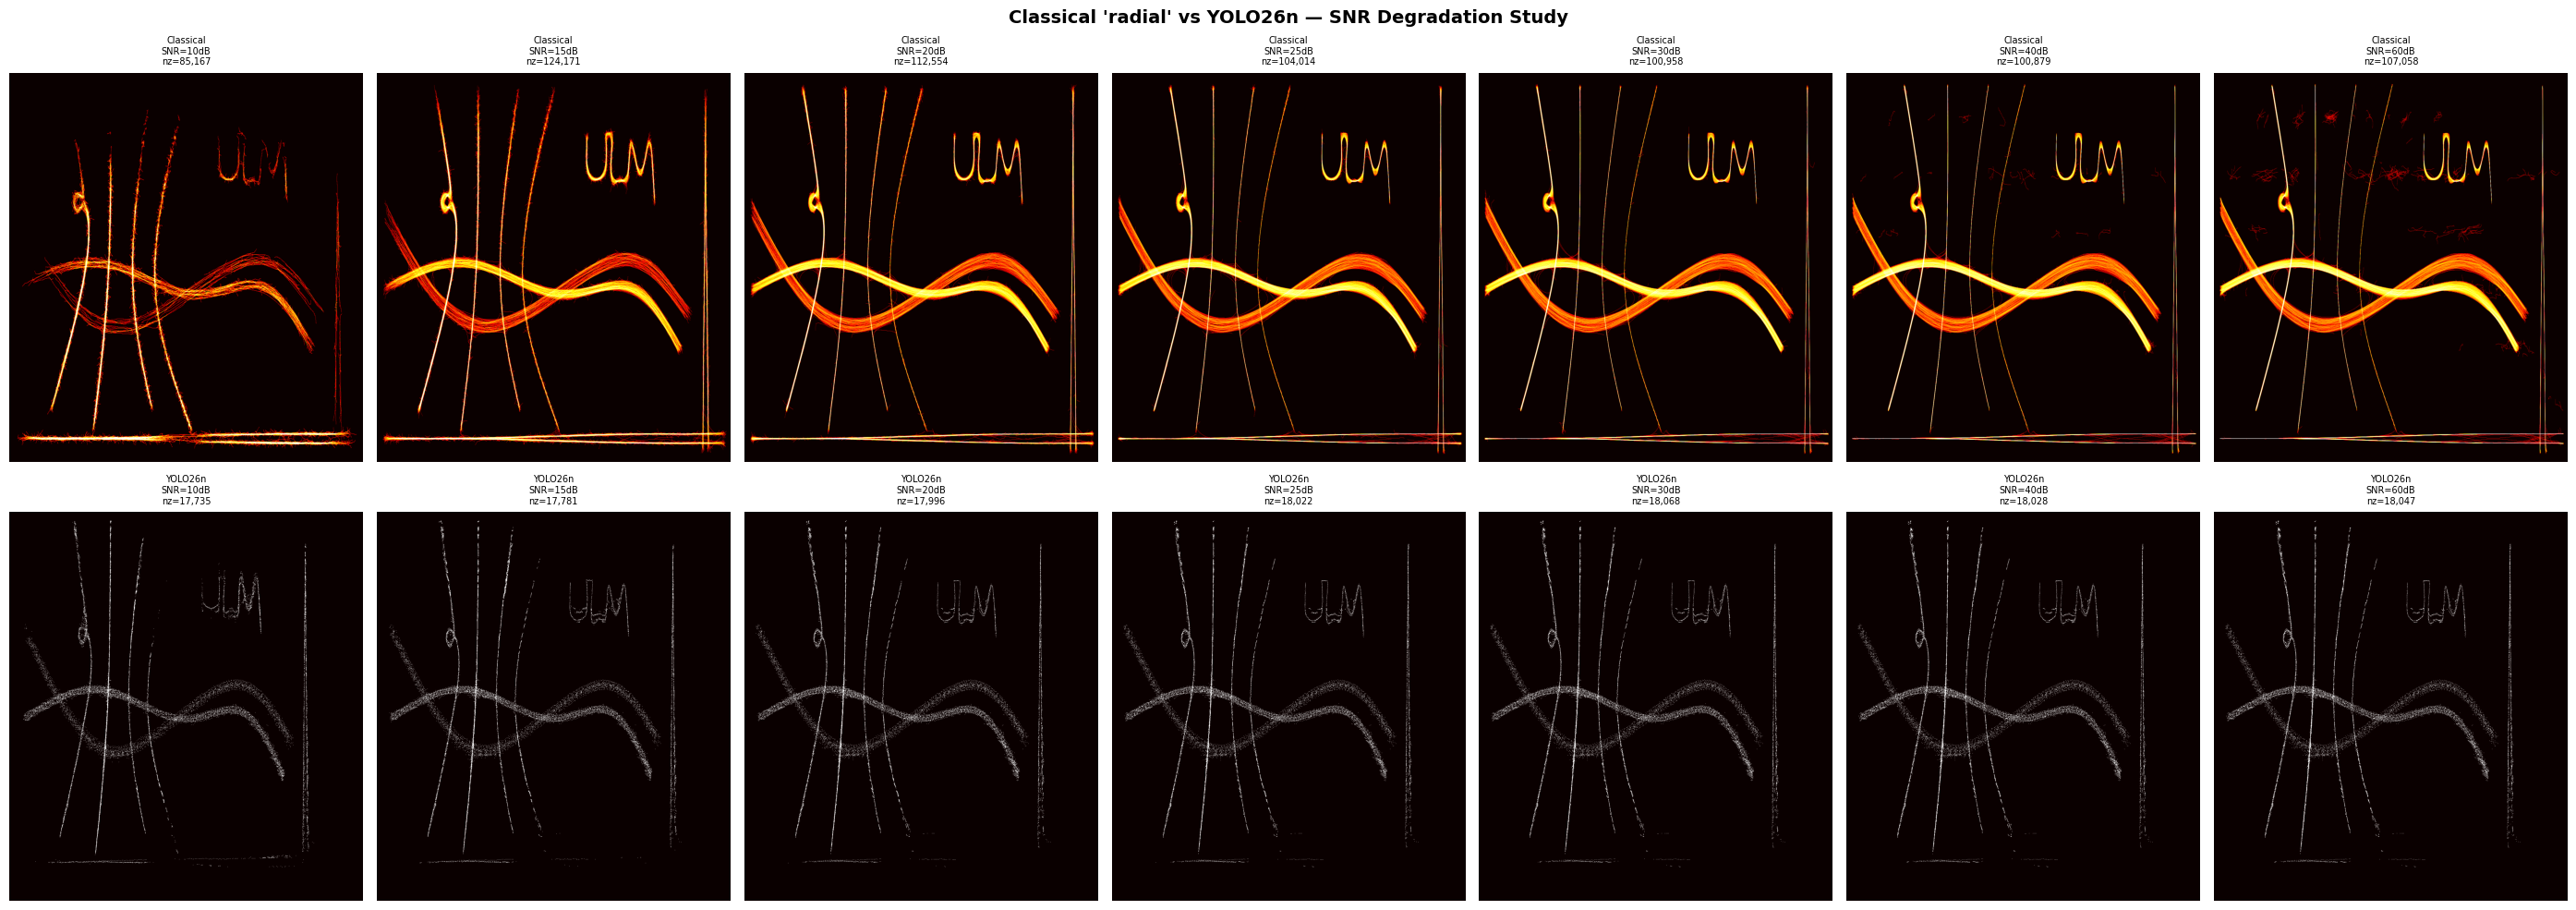

Saved -> /kaggle/working/ulm_outputs/fig9_snr_comparison.png


In [41]:
fig, axes = plt.subplots(2, len(SNR_LEVELS), figsize=(28, 10))
fig.suptitle("Classical 'radial' vs YOLO26n — SNR Degradation Study",
             fontsize=14, fontweight="bold")

for j, snr in enumerate(SNR_LEVELS):
    for row, (img, label) in enumerate([
            (cls_results[snr]["MatOut"], f"Classical\nSNR={snr}dB\nnz={cls_results[snr]['nz']:,}"),
            (dl_results[snr]["MatOut"],  f"YOLO26n\nSNR={snr}dB\nnz={dl_results[snr]['nz']:,}")]):

        ax = axes[row, j]
        if img.max() > 0:
            log_img = np.log1p(img)
            vmax    = np.percentile(log_img, 99.5)
            ax.imshow(log_img, cmap="hot", aspect="auto", vmin=0, vmax=vmax)
        else:
            ax.imshow(np.zeros_like(img), cmap="hot", aspect="auto")
            ax.text(0.5, 0.5, "No det.", transform=ax.transAxes,
                    ha="center", va="center", color="white", fontsize=8)
        ax.set_title(label, fontsize=7)
        ax.axis("off")

plt.tight_layout()
out = OUTPUT_DIR / "fig9_snr_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")


  SNR Robustness Summary
     SNR     CLS nz      DL nz   DL/CLS   DL n_det
  --------------------------------------------------
     10dB     85,167     17,735     4.16x     28,051
     15dB    124,171     17,781     2.86x     28,462
     20dB    112,554     17,996     3.20x     29,231
     25dB    104,014     18,022     3.47x     29,491
     30dB    100,958     18,068     3.58x     29,591
     40dB    100,879     18,028     3.57x     29,587
     60dB    107,058     18,047     3.37x     29,596


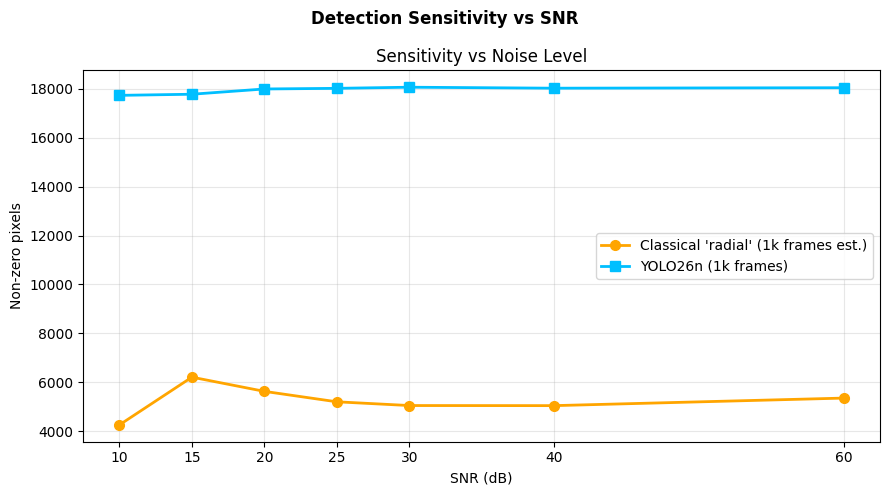

Saved -> /kaggle/working/ulm_outputs/fig10_sensitivity_vs_snr.png


In [44]:
# Summary table
print("\n  SNR Robustness Summary")
print(f"  {'SNR':>6} {'CLS nz':>10} {'DL nz':>10} {'DL/CLS':>8} {'DL n_det':>10}")
print("  " + "-" * 50)
for snr in SNR_LEVELS:
    nz_cls = cls_results[snr]["nz"]
    nz_dl  = dl_results[snr]["nz"]
    ndet   = dl_results[snr]["n_det"]
    ratio  = nz_dl / (nz_cls / 20)   # normalise classical to 1000 frames
    print(f"  {snr:>5}dB {nz_cls:>10,} {nz_dl:>10,} {ratio:>8.2f}x {ndet:>10,}")

# Plot nz vs SNR comparison
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Detection Sensitivity vs SNR", fontsize=12, fontweight="bold")

cls_nz = [cls_results[s]["nz"] / 20 for s in SNR_LEVELS]   # scaled to 1k frames
dl_nz  = [dl_results[s]["nz"]       for s in SNR_LEVELS]

ax.plot(SNR_LEVELS, cls_nz, "o-", color="orange", lw=2, ms=7, label="Classical 'radial' (1k frames est.)")
ax.plot(SNR_LEVELS, dl_nz,  "s-", color="deepskyblue", lw=2, ms=7, label="YOLO26n (1k frames)")
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Non-zero pixels")
ax.set_title("Sensitivity vs Noise Level")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(SNR_LEVELS)

plt.tight_layout()
out = OUTPUT_DIR / "fig10_sensitivity_vs_snr.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

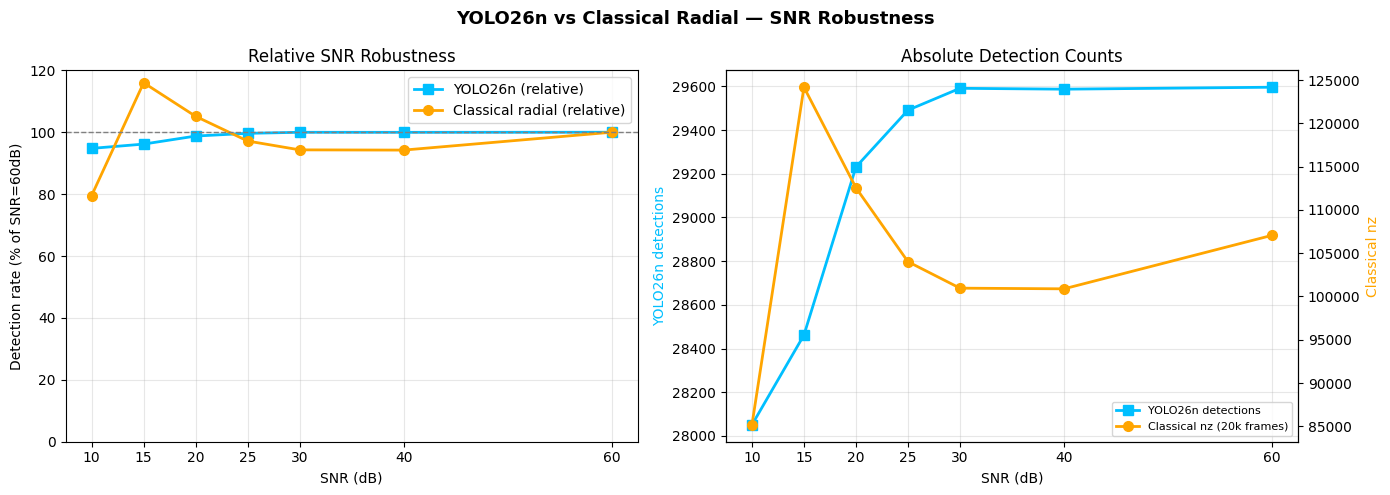

Saved -> /kaggle/working/ulm_outputs/fig10_snr_robustness.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("YOLO26n vs Classical Radial — SNR Robustness",
             fontsize=13, fontweight="bold")

dl_counts  = [dl_results[s]["n_det"] for s in SNR_LEVELS]
dl_nz      = [dl_results[s]["nz"]    for s in SNR_LEVELS]
cls_nz     = [cls_results[s]["nz"]   for s in SNR_LEVELS]

# Normalise to SNR=60dB for relative comparison
dl_norm    = [v / dl_counts[-1]  * 100 for v in dl_counts]
cls_norm   = [v / cls_nz[-1]     * 100 for v in cls_nz]

ax = axes[0]
ax.plot(SNR_LEVELS, dl_norm,  "s-", color="deepskyblue", lw=2, ms=7,
        label="YOLO26n (relative)")
ax.plot(SNR_LEVELS, cls_norm, "o-", color="orange",      lw=2, ms=7,
        label="Classical radial (relative)")
ax.axhline(100, color="gray", ls="--", lw=1)
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Detection rate (% of SNR=60dB)")
ax.set_title("Relative SNR Robustness")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(SNR_LEVELS)
ax.set_ylim(0, 120)

ax = axes[1]
ax.plot(SNR_LEVELS, dl_counts, "s-", color="deepskyblue", lw=2, ms=7,
        label="YOLO26n detections")
ax2 = ax.twinx()
ax2.plot(SNR_LEVELS, cls_nz, "o-", color="orange", lw=2, ms=7,
         label="Classical nz (20k frames)")
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("YOLO26n detections", color="deepskyblue")
ax2.set_ylabel("Classical nz", color="orange")
ax.set_title("Absolute Detection Counts")
ax.grid(True, alpha=0.3); ax.set_xticks(SNR_LEVELS)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
out = OUTPUT_DIR / "fig10_snr_robustness.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")